![Logo del Proyecto](https://www.utdt.edu/Images/prensa/utdt-color-baja.png)

<h1 align="center"> Tesis - Master in Management + Analytics </h1>
<h2 align="center"> IA como Herramienta para el Control de Calidad de Imágenes<br> en el Diagnóstico de Retinopatía Diabética </h2>

**Fecha:** Octubre 2024<br>
**Autora:** Gabriela Moran<br>
**Tutor:** [Santiago Cisco](https://ar.linkedin.com/in/mariocisco)<br>

In [9]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np
import pickle
from matplotlib import pyplot as plt
import multiprocessing as mp 
from multiprocessing import Pool


In [2]:
sys.path.append('./tools')

In [3]:
from some_tools import *

## Estructura de Carpetas

In [4]:
MiM_path = Path(os.getcwd()).parent
BASE = Path(MiM_path/'data')
datasets = os.listdir(BASE/'raw-data/')

In [6]:
# Estructura de carpetas a crear
folders = {BASE.as_posix():
            {'/images':dict.fromkeys(['/'+dataset for dataset in datasets])
            ,'/labels': None
            ,'/splits':None
            ,'/reports':None}
        }

In [7]:
# Crea la estructura de carpetas si aún no estan creadas.
create_folders_scheme(folders)

Created successfully: "c:/Users/gabim/MiM/data/images/DDR-dataset".
Created successfully: "c:/Users/gabim/MiM/data/images/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-".
Created successfully: "c:/Users/gabim/MiM/data/images/HRF - Quality".
Created successfully: "c:/Users/gabim/MiM/data/images/Kaggle".
Created successfully: "c:/Users/gabim/MiM/data/labels".
Created successfully: "c:/Users/gabim/MiM/data/splits".
Created successfully: "c:/Users/gabim/MiM/data/reports".


## Archivo Label
Se crea un archivo pickle para cada dataset, donde se guardará el nombre de archivo y la etiqueta. 

### HRF

In [8]:
raw_HRF = Path(BASE/'raw-data/HRF - Quality')

In [9]:
labels_HRF = pd.DataFrame()
labels_HRF['filename'] = os.listdir(raw_HRF)
labels_HRF['file_path'] = labels_HRF.filename.apply(lambda x: raw_HRF/x)
labels_HRF['label'] = labels_HRF.filename.apply(lambda x: int('bad' in x)) 

In [10]:
labels_HRF.to_pickle(BASE/'labels/HRF.pkl')

### DDR

In [11]:
raw_DDR = Path(BASE/'raw-data/DDR-dataset/DR_grading')

In [12]:
labels_DDR_train = pd.read_csv(raw_DDR/'train.txt',sep=' ', header = None)
labels_DDR_train.columns = ['filename','label']
labels_DDR_train['file_path'] = labels_DDR_train.filename.apply(lambda x: raw_DDR/'train'/x)

labels_DDR_val = pd.read_csv(raw_DDR/'valid.txt',sep=' ', header = None)
labels_DDR_val.columns = ['filename','label']
labels_DDR_val['file_path'] = labels_DDR_val.filename.apply(lambda x: raw_DDR/'valid'/x)


labels_DDR_test = pd.read_csv(raw_DDR/'test.txt',sep=' ', header = None)
labels_DDR_test.columns = ['filename','label']
labels_DDR_test['file_path'] = labels_DDR_test.filename.apply(lambda x: raw_DDR/'test'/x)


labels_DDR = pd.concat([labels_DDR_train, labels_DDR_val, labels_DDR_test],ignore_index=True)

In [13]:
labels_DDR['label'] = labels_DDR['label'].apply(lambda x: 1 if x == 5 else 0)

In [14]:
labels_DDR = labels_DDR.reindex(columns=['filename','file_path','label'])

In [15]:
labels_DDR.to_pickle(BASE/'labels/DDR.pkl')

### Kaggle

In [16]:
raw_kaggle = Path(BASE/'raw-data/Kaggle')

In [17]:
# ZHOU
labels_Zhou_train = pd.read_csv(raw_kaggle/'quality_label_train.csv',sep=',', header = 0)
labels_Zhou_val = pd.read_csv(raw_kaggle/'quality_label_validate.csv',sep=',', header = 0)
labels_Zhou_test = pd.read_csv(raw_kaggle/'quality_label_test.csv',sep=',', header = 0)

In [18]:
labels_kaggle_zhou = pd.concat([labels_Zhou_train,labels_Zhou_val,labels_Zhou_test],ignore_index=True)

In [19]:
labels_kaggle_zhou.columns = ['filename','label']
labels_kaggle_zhou['filename'] = labels_kaggle_zhou.filename.apply(lambda x: x.replace('.jpeg', ''))
labels_kaggle_zhou['filename'] = labels_kaggle_zhou.filename + '.png'
labels_kaggle_zhou['file_path'] = labels_kaggle_zhou.filename.apply(lambda x: raw_kaggle/'images'/x)
labels_kaggle_zhou = labels_kaggle_zhou.reindex(columns=['filename','file_path','label'])

In [20]:
labels_kaggle_zhou['label'] = labels_kaggle_zhou['label'].apply(lambda x: 1 if x == 0 else 0)

In [21]:
labels_kaggle_zhou.to_pickle(BASE/'labels/Kaggle_zhou.pkl')

### Deep Diabetic Retinopathy Image Dataset DeepDRiD

In [22]:
raw_DRiD = Path(BASE/'raw-data/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-')

In [23]:
x = pd.read_csv(raw_DRiD/'regular_fundus_images/regular-fundus-training/regular-fundus-training.csv')
labels_DRiD_train = x.loc[:,['image_path','Overall quality']]
labels_DRiD_train['filename'] = labels_DRiD_train.image_path.apply(lambda x: x.split('\\')[-1])
labels_DRiD_train = labels_DRiD_train.reindex(columns=['filename','image_path','Overall quality'])
labels_DRiD_train.columns = ['filename','file_path','label']
labels_DRiD_train['file_path'] = labels_DRiD_train.filename.apply(lambda x: raw_DRiD/'regular_fundus_images/regular-fundus-training/Images'/x.split('_')[0]/x)
labels_DRiD_train['label']=labels_DRiD_train.label+1
labels_DRiD_train.loc[labels_DRiD_train.label == 2,'label']=0

In [24]:
x = pd.read_csv(raw_DRiD/'regular_fundus_images/regular-fundus-validation/regular-fundus-validation.csv')
labels_DRiD_val = x.loc[:,['image_path','Overall quality']]
labels_DRiD_val['filename'] = labels_DRiD_val.image_path.apply(lambda x: x.split('\\')[-1])
labels_DRiD_val = labels_DRiD_val.reindex(columns=['filename','image_path','Overall quality'])
labels_DRiD_val.columns = ['filename','file_path','label']
labels_DRiD_val['file_path'] = labels_DRiD_val.filename.apply(lambda x: raw_DRiD/'regular_fundus_images/regular-fundus-validation/Images'/x.split('_')[0]/x)
labels_DRiD_val['label']=labels_DRiD_val.label+1
labels_DRiD_val.loc[labels_DRiD_val.label == 2,'label']=0

In [25]:
labels_DRiD = pd.concat([labels_DRiD_train,labels_DRiD_val],ignore_index=True)

In [26]:
labels_DRiD.to_pickle(BASE/'labels/DRiD.pkl')

## Field of view (FOV)

Calcula el FOV y recorta la imagen a su alrededor.

### HRF

In [5]:
with open(BASE/'labels/HRF.pkl','rb') as f:
    HRF = pickle.load(f)

In [6]:
save_to = BASE/'images/HRF - Quality'
HRF_chunks = parallel_arg(HRF,save_to)

In [10]:
with Pool(mp.cpu_count()) as p:
    p.starmap(preprocess_and_save,HRF_chunks)

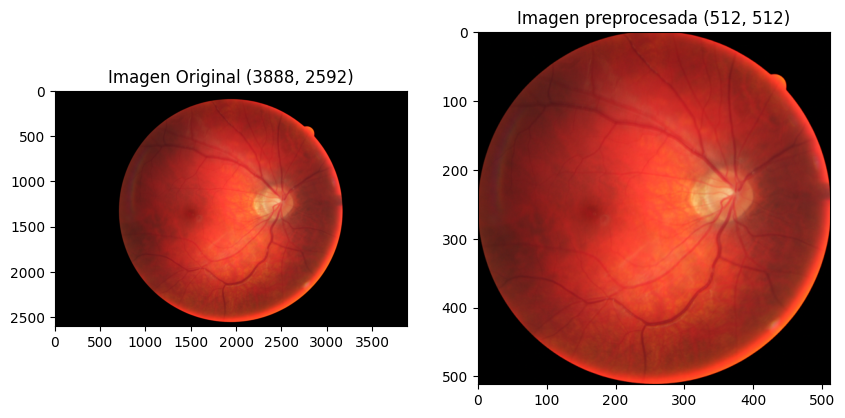

In [11]:
dir_im_original = HRF.file_path.head(1).values.item()
dir_im_prepro = save_to/path.split(dir_im_original.with_suffix('.png'))[-1]

fig, ax = plt.subplots(1, 2, figsize=(10, 10))

im_original = Image.open(dir_im_original) 
ax[0].imshow(im_original)
ax[0].set_title(f'Imagen Original {im_original.size}')

im_prepro = Image.open(dir_im_prepro)
ax[1].imshow(im_prepro,cmap=plt.cm.gray) 
ax[1].set_title(f'Imagen preprocesada {im_prepro.size}')
plt.show()

### DDR

In [12]:
with open(BASE/'labels/DDR.pkl','rb') as f:
    DDR = pickle.load(f)

In [13]:
save_to = BASE/'images/DDR-dataset'
DDR_chunks = parallel_arg(DDR,save_to)

In [14]:
with Pool(mp.cpu_count()) as p:
    p.starmap(preprocess_and_save,DDR_chunks)

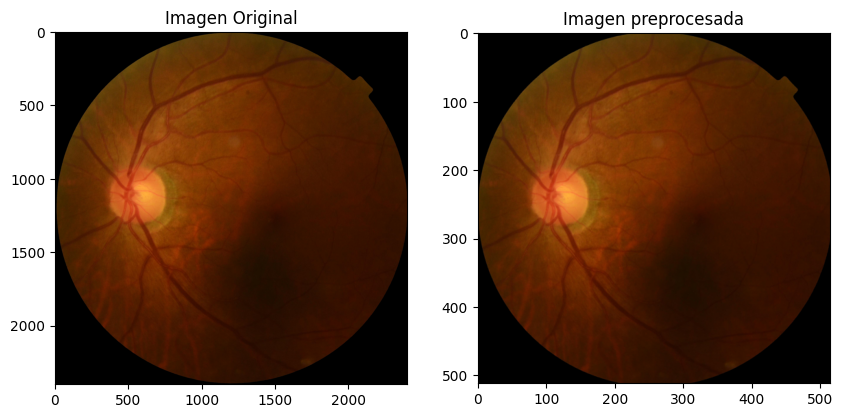

In [ ]:
dir_im_original = DDR.file_path.head(1).values.item()
dir_im_prepro = save_to/path.split(dir_im_original.with_suffix('.png'))[-1]

fig, ax = plt.subplots(1, 2, figsize=(10, 10))

im_original = Image.open(dir_im_original) 
ax[0].imshow(im_original)
ax[0].set_title(f'Imagen Original {im_original.size}')

im_prepro = Image.open(dir_im_prepro)
ax[1].imshow(im_prepro,cmap=plt.cm.gray) 
ax[1].set_title(f'Imagen preprocesada {im_prepro.size}')
plt.show()

### Kaggle

In [6]:
with open(BASE/'labels/Kaggle_zhou.pkl','rb') as f:
    Zhou = pickle.load(f)

In [7]:
save_to = BASE/'images/Kaggle'
kaggle_chunks = parallel_arg(Zhou,save_to)

In [39]:
with Pool(mp.cpu_count()) as p:
    p.starmap(preprocess_and_save,kaggle_chunks)

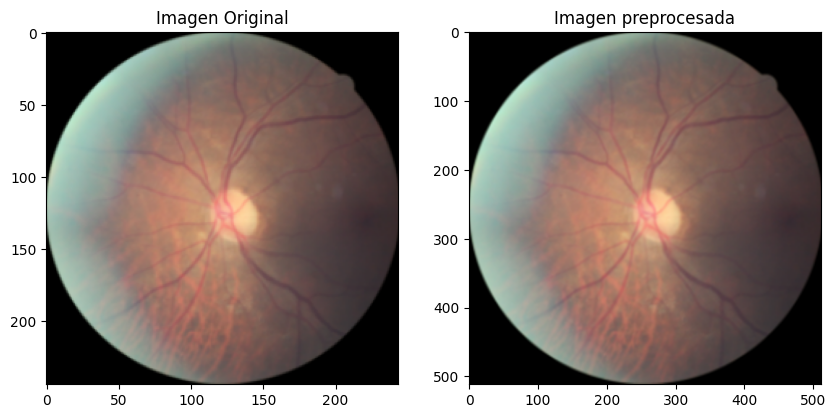

In [41]:
dir_im_original = Zhou.file_path.head(1).values.item()
dir_im_prepro = save_to/path.split(dir_im_original.with_suffix('.png'))[-1]

fig, ax = plt.subplots(1, 2, figsize=(10, 10))


ax[0].imshow(Image.open(dir_im_original))
ax[0].set_title('Imagen Original')

ax[1].imshow(Image.open(dir_im_prepro),cmap=plt.cm.gray) 
ax[1].set_title('Imagen preprocesada')
plt.show()

### Deep Diabetic Retinopathy Image Dataset DeepDRiD

In [42]:
with open(BASE/'labels/DRiD.pkl','rb') as f:
    DRID = pickle.load(f)

In [43]:
save_to = BASE/'images/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-'
preprocess_and_save(DRID,save_to)

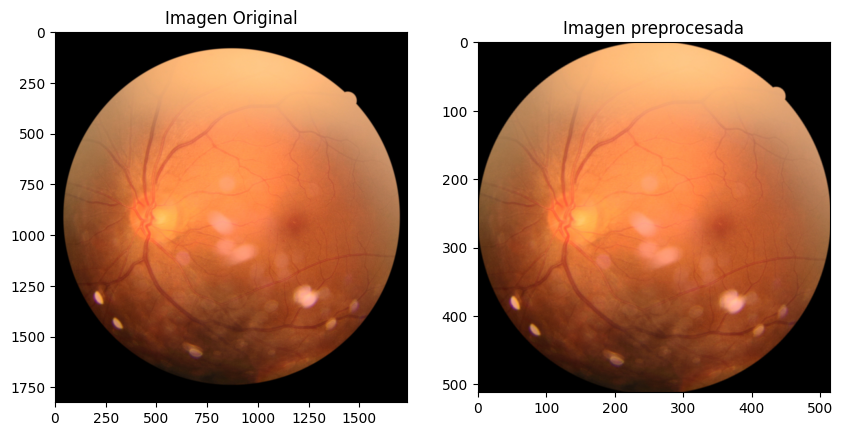

In [44]:
dir_im_original = DRID.file_path.head(1).values.item()
dir_im_prepro = save_to/path.split(dir_im_original.with_suffix('.png'))[-1]

fig, ax = plt.subplots(1, 2, figsize=(10, 10))


ax[0].imshow(Image.open(dir_im_original))
ax[0].set_title('Imagen Original')

ax[1].imshow(Image.open(dir_im_prepro),cmap=plt.cm.gray) 
ax[1].set_title('Imagen preprocesada')
plt.show()